 Library Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


Data Acquisition

In [4]:
data = pd.read_csv("Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

Data Inspection

In [5]:
data.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


Data Schema and Integrity Check

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

Descriptive Statistics

In [7]:
data.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


Missing Value Analysis

In [8]:
data.isnull().sum()

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

Distribution Visualization

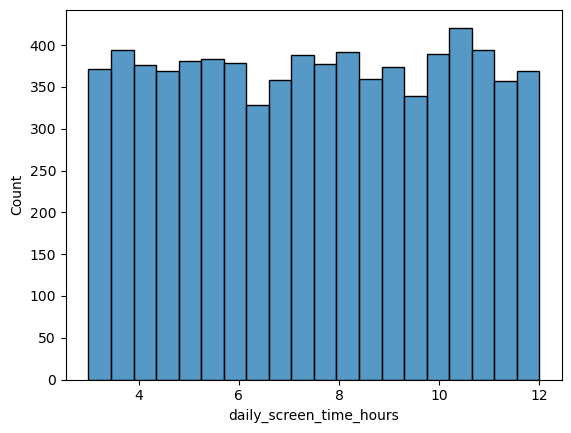

In [9]:
sns.histplot(data['daily_screen_time_hours'])
plt.show()

 Bivariate Distribution (Screen Time vs. Addiction)

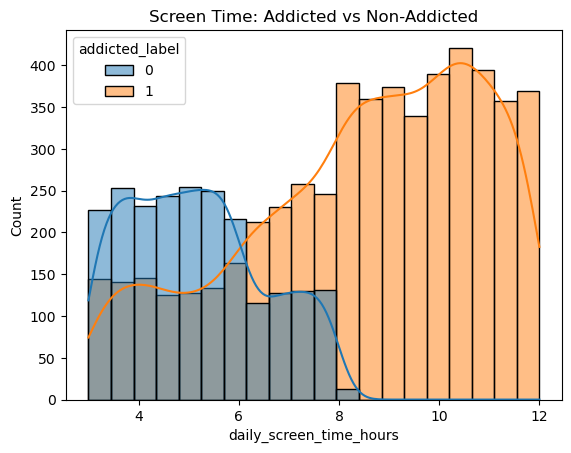

In [10]:
# difference in screen time between addicted and non-addicted users
# This plot is what data scientists call a Smoking Gun
# By adding the hue and kde=True (the smooth line), you are performing 
# Bivariate Analysis to see if your target variable actually depends on this feature.
sns.histplot(data=data, x='daily_screen_time_hours', hue='addicted_label', kde=True)
plt.title("Screen Time: Addicted vs Non-Addicted")
plt.show()


Correlation Heatmap


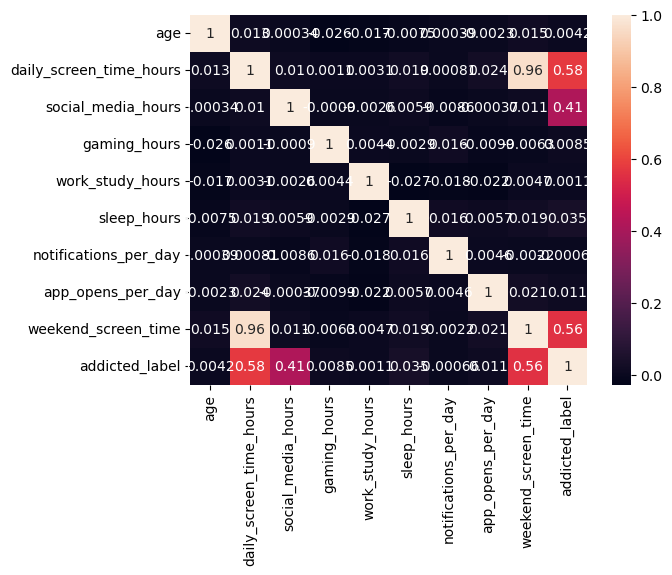

In [11]:
# This is a Correlation Matrix. It calculates a "score" (from -1 to 1) 
# for every pair of numerical features to see how they move together.
numeric_data = data.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_data.corr(), annot=True)
plt.show()

Target Variable Balance (Countplot)

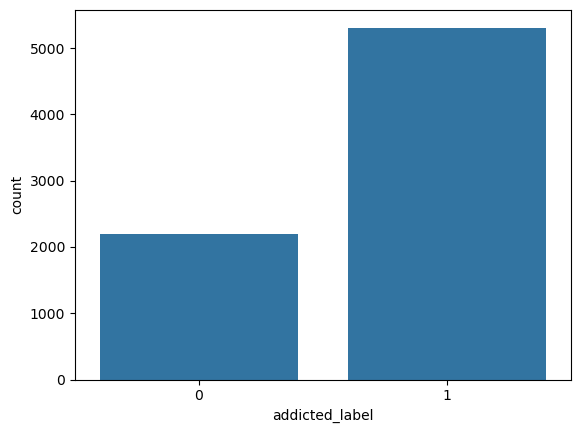

In [12]:
# This is a Countplot for your target variable, addicted_label. 
# It is a fundamental visualization used to check for Class Imbalance.
sns.countplot(x='addicted_label', data=data)
plt.show()

 Label Encoding (Categorical to Numerical)

In [13]:
#encoding
data['gender'] = data['gender'].astype('category').cat.codes
data['stress_level'] = data['stress_level'].astype('category').cat.codes
data['academic_work_impact'] = data['academic_work_impact'].astype('category').cat.codes

Feature Selection (X and y)

In [14]:
X = data[[
'age',
'gender',
'daily_screen_time_hours',
'social_media_hours',
'gaming_hours',
'work_study_hours',
'sleep_hours',
'notifications_per_day',
'app_opens_per_day',
'weekend_screen_time',
'stress_level',
'academic_work_impact'
]]

y = data['addicted_label']

Data Splitting (Train/Test Split)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Dimension Verification


In [16]:
data.shape
X.shape
y.shape
print(data.shape)
print(X.shape)
print(y.shape)

(7500, 16)
(7500, 12)
(7500,)


Model Training (Random Forest)

In [17]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

Model Evaluation

In [18]:
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)
print(classification_report(y_test, predictions))

Accuracy: 0.9233333333333333
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       456
           1       0.95      0.94      0.94      1044

    accuracy                           0.92      1500
   macro avg       0.91      0.91      0.91      1500
weighted avg       0.92      0.92      0.92      1500



Confusion Matrix Visualization

[[405  51]
 [ 64 980]]


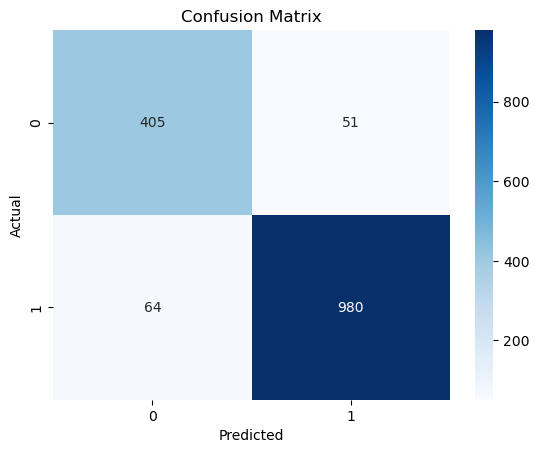

In [19]:
cm = confusion_matrix(y_test, predictions)
print(cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Feature Importance Ranking

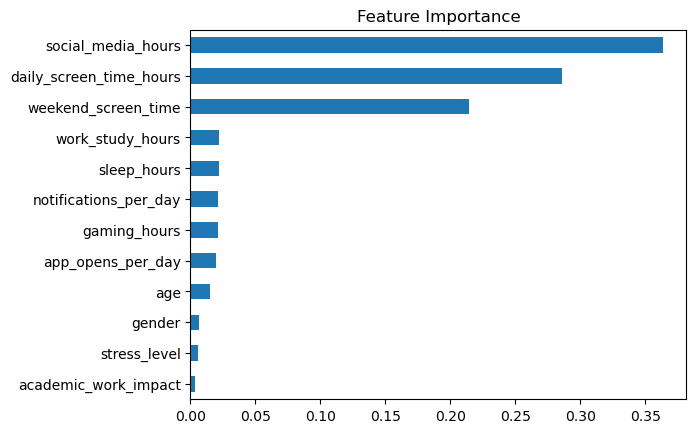

In [20]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

In [21]:
#SHAP will explain
#WHY the model predicted addicted

SHAP (SHapley Additive exPlanations) Integration

In [22]:
import shap

SHAP TreeExplainer Initialization

In [23]:
explainer = shap.TreeExplainer(model)
print(X_test.shape)
shap_values = explainer.shap_values(X_test)

(1500, 12)


SHAP Summary Plot

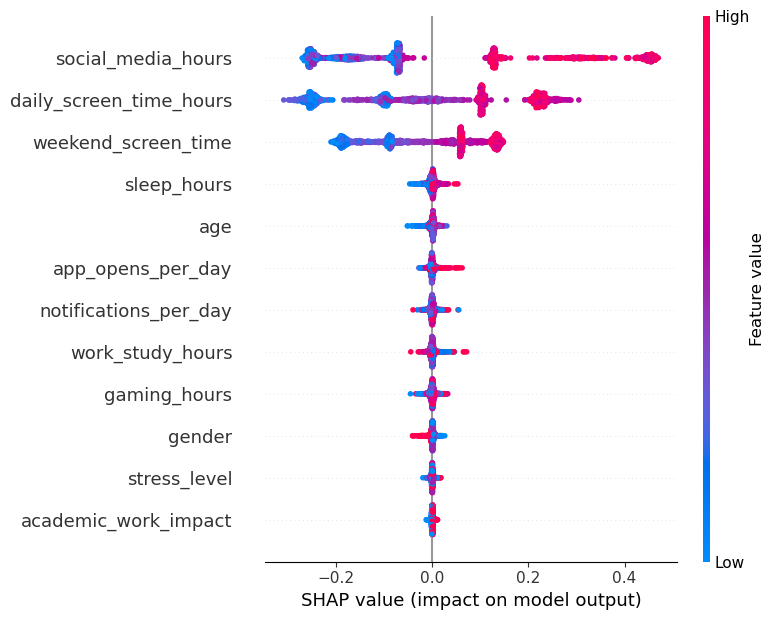

In [24]:
shap.summary_plot(shap_values[:, :, 1], X_test)

SHAP Global Feature Importance

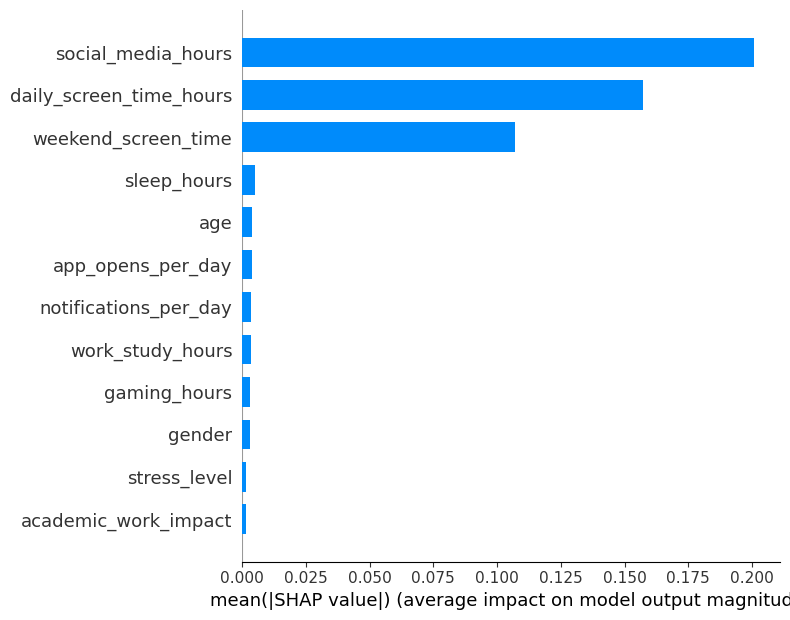

In [25]:
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar")
#It shows that weekend behavior is a major differentiator. 
# To address Research Gap 1, my system can use this insight 
# to preemptively 'nudge' the user on Friday evenings, 
# predicting that their weekend patterns typically lead to high-risk states

In [26]:
# Initialize JavaScript (required for force_plot)
index = 1
print(len(X_test.iloc[index]))
print(len(shap_values[1][index]))
print(np.array(shap_values).shape)
shap.initjs()# This gives you all 12 features for that specific row and class
class_1_shap_values = shap_values[index, :, 1] 

shap.force_plot(
    explainer.expected_value[1], 
    class_1_shap_values, 
    X_test.iloc[index]
)

#Addressing Research Gap 5: This directly fulfills the need for transparency. 
# Instead of just saying "You are at risk," the system can now show the specific 
# reasons why for that exact moment.

12
2
(1500, 12, 2)


In [27]:
#Closing the Loop on Research Gap 1 (Personalised Predictive Intervention)
#Explainability (SHAP), Accuracy (93%).

SHAP Waterfall Plot (Legacy Waterfall)

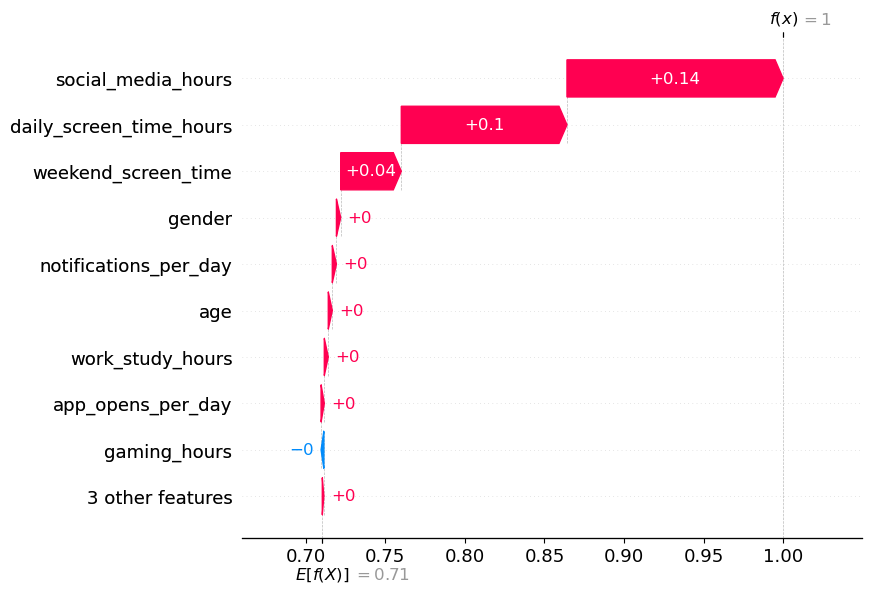

In [28]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[1],
    class_1_shap_values,
    feature_names=X.columns
)

Individual Explainability DataFrame

In [29]:
user = X_test.iloc[index]
shap_vals = shap_values[index, :, 1]

shap_df = pd.DataFrame({
    "feature": X_test.columns,
    "value": user.values,
    "impact": shap_vals
})

shap_df = shap_df.sort_values(by="impact", ascending=False)
print(shap_df)

                    feature   value    impact
3        social_media_hours    5.33  0.135851
2   daily_screen_time_hours    8.10  0.104138
9       weekend_screen_time   10.05  0.038089
1                    gender    0.00  0.002686
7     notifications_per_day  187.00  0.002595
0                       age   25.00  0.002523
5          work_study_hours    1.73  0.002503
8         app_opens_per_day  177.00  0.002014
6               sleep_hours    7.11  0.001481
10             stress_level    1.00  0.000357
11     academic_work_impact    0.00 -0.000876
4              gaming_hours    0.04 -0.001725


The Intervention Engine

In [30]:
recommendations = []

# Sort by impact to prioritize the features PUSHING the user toward addiction
top_risks = shap_df.sort_values(by="impact", ascending=False)

for _, row in top_risks.iterrows():
    feature = row["feature"]
    value = row["value"]
    impact = row["impact"]

    # BI-DIRECTIONAL PREDICTIVE LOGIC
    # We only intervene if the SHAP impact is significantly positive (> 0.01)
    if impact > 0.01: 
        if feature == "social_media_hours":
            recommendations.append(f"Predictive Alert: Your social media pattern ({value} hrs) is currently the primary driver of your addiction risk. Consider a 15-minute break now to stay in the 'Low' risk zone.")

        elif feature == "daily_screen_time_hours":
            recommendations.append(f"Proactive Nudge: Total screen time is trending high. Our model predicts this will increase digital fatigue. Aim to keep usage below your current {value} hrs.")

        elif feature == "sleep_hours":
            recommendations.append(f"Wellbeing Insight: Lack of sleep ({value} hrs) is mathematically increasing your vulnerability to digital addiction. Prioritize rest tonight to improve focus.")

        elif feature == "app_opens_per_day":
            recommendations.append(f"Behavioral Trigger: Frequent app checking ({value} times) is creating 'switch-tasking' stress. Try enabling 'Do Not Disturb' to reduce this risk factor.")

Human-Centric Feedback Wrapper

In [31]:
print("Addiction Risk Score:", model.predict_proba(user.to_frame().T))

print("\nTop Factors:")
print(shap_df.head(3))

if not recommendations:
    print("Keep it up! Your current habits are not showing significant addiction risks.")
else:
    print("Recommendations:")
    for r in recommendations:
        print("•", r)

Addiction Risk Score: [[0. 1.]]

Top Factors:
                   feature  value    impact
3       social_media_hours   5.33  0.135851
2  daily_screen_time_hours   8.10  0.104138
9      weekend_screen_time  10.05  0.038089
Recommendations:
• Predictive Alert: Your social media pattern (5.33 hrs) is currently the primary driver of your addiction risk. Consider a 15-minute break now to stay in the 'Low' risk zone.
• Proactive Nudge: Total screen time is trending high. Our model predicts this will increase digital fatigue. Aim to keep usage below your current 8.1 hrs.


Final Risk Classification & Tiering

In [32]:
risk_score = model.predict_proba(user.to_frame().T)[0][1]

if risk_score > 0.7:
    level = "High"
elif risk_score > 0.4:
    level = "Moderate"
else:
    level = "Low"

print(f"Addiction Risk Level: {level} ({risk_score:.2f})")

Addiction Risk Level: High (1.00)


Export Method (ONNX)

In [33]:
from skl2onnx import to_onnx
from skl2onnx.common.data_types import FloatTensorType
import json

# 1. Define the input type
initial_type = [('float_input', FloatTensorType([None, 12]))]

# 2. CRITICAL: Disable ZipMap to get a standard Tensor output (no more Sparse errors!)
options = {type(model): {'zipmap': False}}

# 3. Convert with the options
onx = to_onnx(model, initial_types=initial_type, options=options, target_opset=15)

# 4. Save the model
with open("wellbeing_model.onnx", "wb") as f:
    f.write(onx.SerializeToString())

# 5. Save the features
with open("feature_map.json", "w") as f:
    json.dump({"features": X.columns.tolist()}, f)

print("✅ Success: Model re-exported as a standard Dense Tensor!")


✅ Success: Model re-exported as a standard Dense Tensor!


Testing the ONNX Model 

In [34]:

import onnxruntime as rt

# 1. Load the ONNX model and create a session
providers = ['CPUExecutionProvider']
sess = rt.InferenceSession("wellbeing_model.onnx", providers=providers)

# 2. Identify the input and output names (we defined 'float_input' earlier)
input_name = sess.get_inputs()[0].name
# For sklearn classifiers, index 0 is labels, index 1 is probabilities
output_name = sess.get_outputs()[1].name 

# 3. Prepare test data (Take a sample from your X_test)
# ONNX is strict: must be float32 and have batch dimension [1, 12]
sample_idx = 0
sample_input = X_test.iloc[sample_idx:sample_idx+1].values.astype(np.float32)


# 4. Run Inference in ONNX
onnx_results = sess.run([output_name], {input_name: sample_input})
onnx_prob = onnx_results[0][0][1] # Probability of 'Addicted' (Class 1)

# 5. Run Inference in Scikit-Learn (Original)
original_prob = model.predict_proba(sample_input)[0][1]

# 6. Compare Results
print(f"--- Parity Test for User {sample_idx} ---")
print(f"Original Model (SKLearn) Prob: {original_prob:.4f}")
print(f"Exported Model (ONNX) Prob:    {onnx_prob:.4f}")

if np.isclose(original_prob, onnx_prob, atol=1e-5):
    print("✅ PASS: The ONNX model is perfectly identical to the original!")
else:
    print("❌ FAIL: There is a discrepancy between the models.")

--- Parity Test for User 0 ---
Original Model (SKLearn) Prob: 0.3800
Exported Model (ONNX) Prob:    0.3800
✅ PASS: The ONNX model is perfectly identical to the original!


c:\Users\PMLS\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
